# MIE1517 Project Progress Report Notebook

**Group:** 10  
**Project:** Conditional bird-chirp generation  
**Report scope:** Data cleaning, quality control, EDA, and leakage-safe dataset preparation.


## 0. Executive Summary

This notebook reports the completed data pipeline milestone derived from `data_cleaning_eda_template.ipynb` outputs.

Current status:
- Raw corpus indexed and validated.
- Metadata merged into a unified manifest.
- Quality control and duplicate filtering applied.
- Leakage-safe train/validation/test split produced by `recording_id`.
- Final training artifacts exported for model development.

The remaining project work is model training, generation quality optimization, and quantitative/audio evaluation.


## 1. Setup and Data Loading


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import librosa
import librosa.display
from IPython.display import Audio, display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)


In [2]:
ROOT = Path.cwd()
ARTIFACTS = ROOT / "artifacts"

paths = {
    "manifest_full": ARTIFACTS / "manifest_full.parquet",
    "manifest_clean": ARTIFACTS / "manifest_clean.parquet",
    "manifest_train_ready": ARTIFACTS / "manifest_train_ready.parquet",
    "train_csv": ARTIFACTS / "train.csv",
    "val_csv": ARTIFACTS / "val.csv",
    "test_csv": ARTIFACTS / "test.csv",
    "label2idx": ARTIFACTS / "label2idx.json",
}

missing = [k for k, p in paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError(f"Missing artifacts: {missing}. Run data_cleaning_eda_template.ipynb first.")

manifest_full = pd.read_parquet(paths["manifest_full"])
manifest_clean = pd.read_parquet(paths["manifest_clean"])
manifest_train_ready = pd.read_parquet(paths["manifest_train_ready"])

train_df = pd.read_csv(paths["train_csv"])
val_df = pd.read_csv(paths["val_csv"])
test_df = pd.read_csv(paths["test_csv"])

print("manifest_full:", manifest_full.shape)
print("manifest_clean:", manifest_clean.shape)
print("manifest_train_ready:", manifest_train_ready.shape)
print("train/val/test:", len(train_df), len(val_df), len(test_df))


manifest_full: (9107, 33)
manifest_clean: (9107, 43)
manifest_train_ready: (5348, 45)
train/val/test: 3742 815 791


In [3]:
summary = pd.DataFrame([
    {
        "metric": "total_audio_files",
        "value": int(len(manifest_full)),
    },
    {
        "metric": "labeled_files",
        "value": int(manifest_full["label_known"].sum()),
    },
    {
        "metric": "unlabeled_files",
        "value": int((manifest_full["label_known"] == 0).sum()),
    },
    {
        "metric": "kept_for_training",
        "value": int(manifest_clean["keep_for_training"].sum()),
    },
    {
        "metric": "dropped_qc_flagged",
        "value": int((manifest_clean["drop_reason"] == "qc_flagged").sum()),
    },
    {
        "metric": "dropped_exact_duplicates",
        "value": int((manifest_clean["drop_reason"] == "exact_duplicate").sum()),
    },
    {
        "metric": "train_rows",
        "value": int(len(train_df)),
    },
    {
        "metric": "val_rows",
        "value": int(len(val_df)),
    },
    {
        "metric": "test_rows",
        "value": int(len(test_df)),
    },
    {
        "metric": "unique_species_kept",
        "value": int(manifest_train_ready["species_label"].nunique()),
    },
])
summary


,metric,value
0,total_audio_files,9107
1,labeled_files,5422
2,unlabeled_files,3685
3,kept_for_training,5348
4,dropped_qc_flagged,50
5,dropped_exact_duplicates,24
6,train_rows,3742
7,val_rows,815
8,test_rows,791
9,unique_species_kept,5


## 2. Dataset Overview


In [4]:
raw_labeled_counts = (
    manifest_full[manifest_full["label_known"] == 1]["species_label"]
    .value_counts()
    .sort_values(ascending=False)
)
kept_counts = manifest_train_ready["species_label"].value_counts().reindex(raw_labeled_counts.index)

comparison = pd.DataFrame({
    "raw_labeled": raw_labeled_counts,
    "kept_after_cleaning": kept_counts,
})
comparison


,raw_labeled,kept_after_cleaning
species_label,,
Melospiza melodia,1256,1223
Mimus polyglottos,1182,1177
Cardinalis cardinalis,1074,1064
Turdus migratorius,1017,998
Thryomanes bewickii,893,886


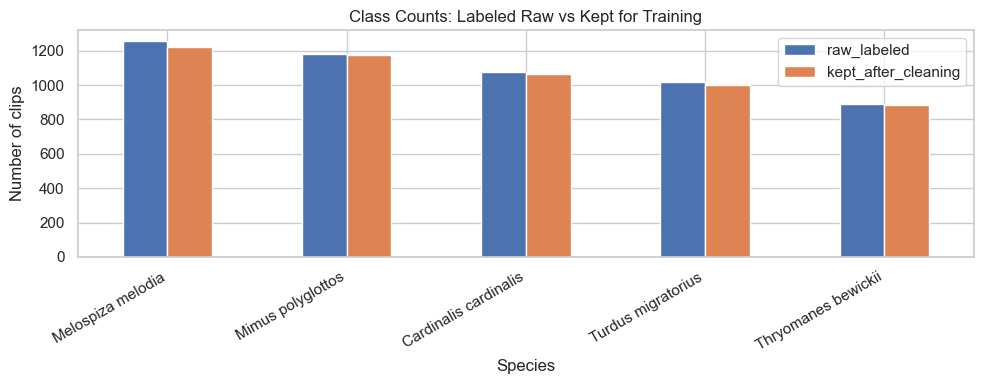

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
comparison.plot(kind="bar", ax=ax)
ax.set_title("Class Counts: Labeled Raw vs Kept for Training")
ax.set_xlabel("Species")
ax.set_ylabel("Number of clips")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [6]:
tech_summary = pd.DataFrame([
    {
        "attribute": "sample_rates",
        "value": dict(manifest_full["sr"].value_counts().sort_index()),
    },
    {
        "attribute": "duration_sec_min_median_max",
        "value": (
            float(manifest_full["duration_sec"].min()),
            float(manifest_full["duration_sec"].median()),
            float(manifest_full["duration_sec"].max()),
        ),
    },
    {
        "attribute": "channels",
        "value": dict(manifest_full["channels"].value_counts().sort_index()),
    },
    {
        "attribute": "read_errors",
        "value": int(manifest_full["read_error"].sum()),
    },
])
tech_summary


,attribute,value
0,sample_rates,{22050: 9107}
1,duration_sec_min_median_max,"(3.0, 3.0, 3.0)"
2,channels,{1: 9107}
3,read_errors,0


## 3. Cleaning and Quality-Control Outcomes


In [7]:
drop_reason_counts = (
    manifest_clean["drop_reason"]
    .replace("", "kept")
    .value_counts()
    .rename_axis("reason")
    .to_frame("count")
)

drop_reason_counts


,count
reason,
kept,5348
unlabeled,3685
qc_flagged,50
exact_duplicate,24


In [8]:
qc_summary = pd.DataFrame([
    {
        "flag": "flag_low_energy",
        "count": int(manifest_clean["flag_low_energy"].sum()),
    },
    {
        "flag": "flag_clipping",
        "count": int(manifest_clean["flag_clipping"].sum()),
    },
    {
        "flag": "flag_dc_offset",
        "count": int(manifest_clean["flag_dc_offset"].sum()),
    },
    {
        "flag": "flag_bad",
        "count": int(manifest_clean["flag_bad"].sum()),
    },
    {
        "flag": "exact_duplicates_removed",
        "count": int((manifest_clean["drop_reason"] == "exact_duplicate").sum()),
    },
    {
        "flag": "near_duplicates_removed",
        "count": int(manifest_clean["flag_near_dup"].sum()),
    },
])
qc_summary


,flag,count
0,flag_low_energy,92
1,flag_clipping,0
2,flag_dc_offset,28
3,flag_bad,120
4,exact_duplicates_removed,24
5,near_duplicates_removed,0


## 4. Split Quality and Leakage Checks


In [9]:
split_counts = manifest_train_ready["split"].value_counts().rename_axis("split").to_frame("count")
split_counts


,count
split,
train,3742
val,815
test,791


In [10]:
split_by_class = pd.crosstab(
    manifest_train_ready["split"],
    manifest_train_ready["species_label"],
    normalize="index",
)
split_by_class


species_label,Cardinalis cardinalis,Melospiza melodia,Mimus polyglottos,Thryomanes bewickii,Turdus migratorius
split,,,,,
test,0.190898,0.238938,0.211125,0.165613,0.193426
train,0.200962,0.223143,0.222341,0.169161,0.184393
val,0.197546,0.244172,0.218405,0.149693,0.190184


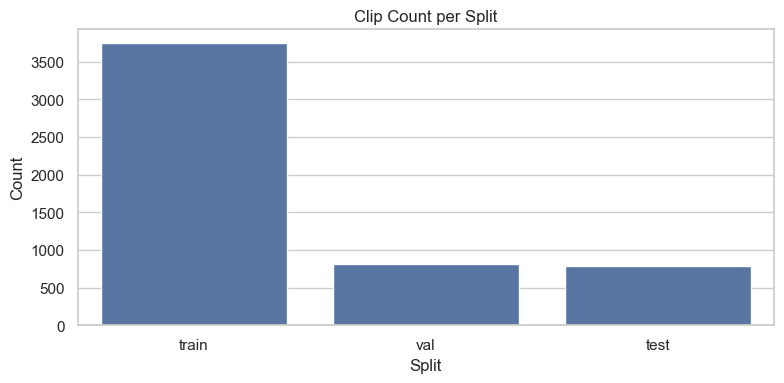

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
sns.countplot(data=manifest_train_ready, x="split", order=["train", "val", "test"], ax=ax)
ax.set_title("Clip Count per Split")
ax.set_xlabel("Split")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


In [12]:
max_splits_per_group = manifest_train_ready.groupby("recording_id")["split"].nunique().max()
multi_species_groups = int((manifest_train_ready.groupby("recording_id")["species_label"].nunique() > 1).sum())

split_sets = {
    s: set(manifest_train_ready.loc[manifest_train_ready["split"] == s, "recording_id"].astype(str))
    for s in ["train", "val", "test"]
}

integrity = pd.DataFrame([
    {"check": "max_splits_per_recording_id", "value": int(max_splits_per_group)},
    {"check": "recording_ids_with_multiple_species", "value": multi_species_groups},
    {"check": "train_val_group_overlap", "value": int(len(split_sets["train"].intersection(split_sets["val"])))},
    {"check": "train_test_group_overlap", "value": int(len(split_sets["train"].intersection(split_sets["test"])))},
    {"check": "val_test_group_overlap", "value": int(len(split_sets["val"].intersection(split_sets["test"])))},
])

integrity


,check,value
0,max_splits_per_recording_id,1
1,recording_ids_with_multiple_species,0
2,train_val_group_overlap,0
3,train_test_group_overlap,0
4,val_test_group_overlap,0


## 5. Sample Inspection


C:\Users\Legion\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


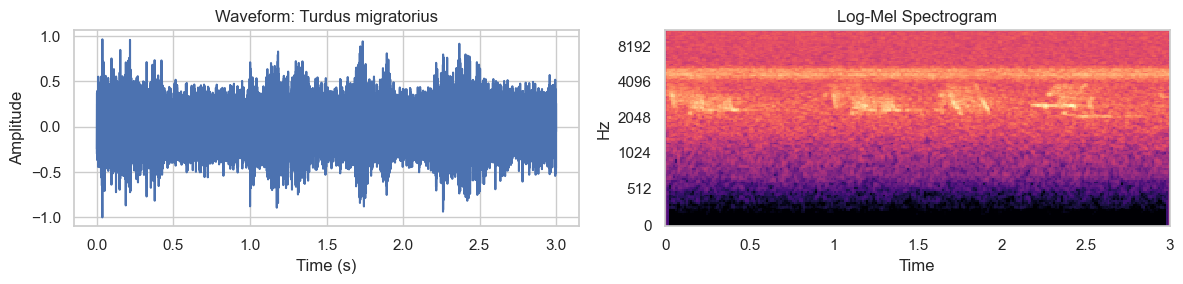

File: 562449-10.wav
Split: train
Label: Turdus migratorius


In [13]:
sample = train_df.sample(1, random_state=42).iloc[0]
path = Path(sample["filepath"])

y, sr = librosa.load(path, sr=22050, mono=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].plot(np.arange(len(y)) / sr, y)
ax[0].set_title(f"Waveform: {sample['species_label']}")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Amplitude")

S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=1024, hop_length=256, n_mels=128, fmin=20, fmax=10000)
S_db = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_db, sr=sr, hop_length=256, x_axis="time", y_axis="mel", ax=ax[1])
ax[1].set_title("Log-Mel Spectrogram")

plt.tight_layout()
plt.show()

print("File:", sample["filename"])
print("Split:", sample["split"])
print("Label:", sample["species_label"])
display(Audio(y, rate=sr))


## 6. Delivered Artifacts


In [14]:
artifact_rows = []
for p in sorted(ARTIFACTS.glob("*")):
    if p.is_file():
        artifact_rows.append(
            {
                "file": p.name,
                "size_kb": round(p.stat().st_size / 1024, 2),
            }
        )

artifact_table = pd.DataFrame(artifact_rows).sort_values("file").reset_index(drop=True)
artifact_table


,file,size_kb
0,label2idx.json,0.14
1,manifest_clean.parquet,400.09
2,manifest_full.parquet,227.68
3,manifest_train_ready.parquet,267.56
4,test.csv,433.50
5,train.csv,2019.23
6,val.csv,456.21


## 7. Interpretation and Next Engineering Tasks

What is complete:
- The dataset pipeline is reproducible and produces stable train/validation/test splits.
- Data leakage by recording group is controlled.
- Training-ready tables and label mappings are exported for downstream modeling.

What remains:
1. Train conditional generation baselines using `train.csv`, `val.csv`, and `test.csv`.
2. Add generation-focused metrics and listening-test protocol in the model notebook.
3. Evaluate whether enabling near-duplicate filtering improves generalization.
4. Compare conditioning architectures (cGAN and cVAE) under the same split.


## Appendix - Export Command

`jupyter nbconvert --to html --execute "MIE1517_progress_report_skeleton.ipynb" --output "MIE1517_progress_report.html" --ExecutePreprocessor.timeout=1200`
